# Лабораторная работа 2. Сэмплинг

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE

sns.set_style("whitegrid")

c:\Users\ichap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


ImportError: cannot import name '_is_pandas_df' from 'sklearn.utils.validation' (c:\Users\ichap\anaconda3\Lib\site-packages\sklearn\utils\validation.py)

## Загрузка данных

In [ ]:
dataset_path = "../../datasets/gtzan/features_30_sec.csv"
data = pd.read_csv(dataset_path)

print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} столбцов")
data.head()

Размер датасета: 1000 строк, 60 столбцов


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


## Описательная статистика

In [ ]:
data.describe()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


## Анализ баланса классов

Датасет GTZAN содержит 10 жанров по 100 записей каждый — идеально сбалансированный набор. Для демонстрации методов сэмплинга **искусственно дебалансируем каждый из 10 классов**, оставив случайную долю записей. Так получится правдоподобный сценарий многоклассовой задачи с разными размерами классов — на нём `imblearn` (RUS, ROS, SMOTE, Tomek Links) показывают свою работу куда более реалистично, чем на бинарной jazz-vs-остальные.

C:\Users\ichap\AppData\Local\Temp\ipykernel_49828\2065067944.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=original_counts.index, y=original_counts.values, palette="viridis", ax=axes[0])
C:\Users\ichap\AppData\Local\Temp\ipykernel_49828\2065067944.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imb_counts.index, y=imb_counts.values, palette="tab10", ax=axes[1])


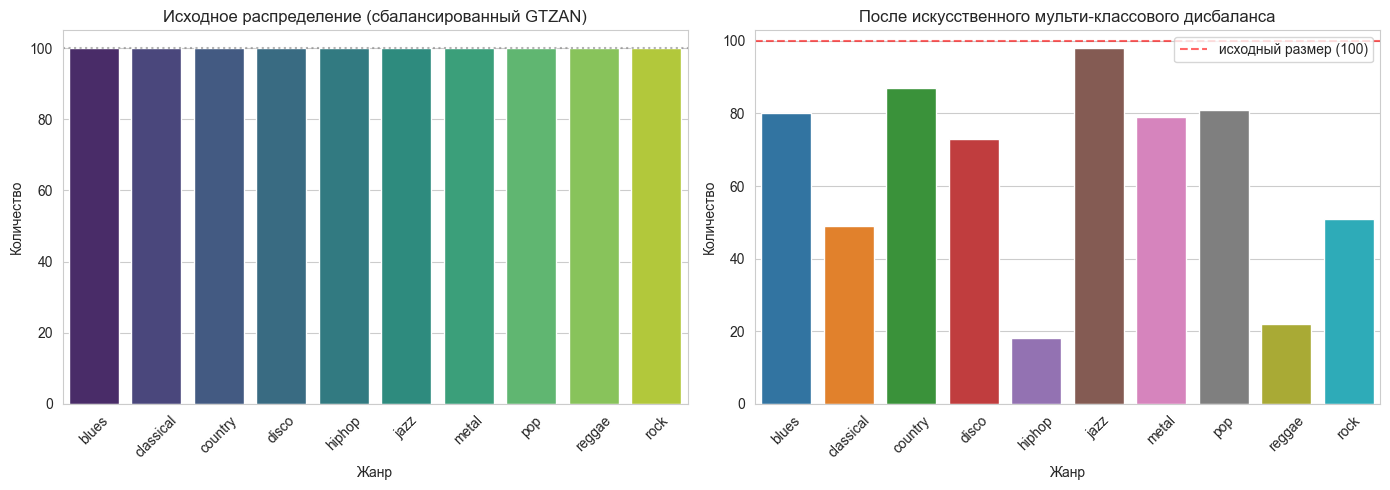

Размеры классов после дебаланса:
  blues     :  80  (доля 0.80)
  classical :  49  (доля 0.49)
  country   :  87  (доля 0.87)
  disco     :  73  (доля 0.73)
  hiphop    :  18  (доля 0.18)
  jazz      :  98  (доля 0.98)
  metal     :  79  (доля 0.79)
  pop       :  81  (доля 0.81)
  reggae    :  22  (доля 0.22)
  rock      :  51  (доля 0.51)

Всего записей: 638 (было 1000)
Min: 18 (hiphop), Max: 98 (jazz)
Imbalance ratio (max/min): 5.44


In [ ]:
# 1. Случайные пропорции для каждого жанра (фиксированный seed → воспроизводимо)
GENRES = sorted(data["label"].unique())
rng = np.random.default_rng(42)
imbalance_ratios = {g: rng.uniform(0.1, 1.0) for g in GENRES}
keep_counts = {g: max(10, int(round(100 * r))) for g, r in imbalance_ratios.items()}

# 2. Создаём дебалансированный датасет: для каждого жанра берём свою долю записей
imbalanced = pd.concat([
    data[data["label"] == g].sample(n=keep_counts[g], random_state=42)
    for g in GENRES
]).reset_index(drop=True)

# 3. Визуализация: сравниваем исходное и новое распределение
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

original_counts = data["label"].value_counts().reindex(GENRES)
sns.barplot(x=original_counts.index, y=original_counts.values, palette="viridis", ax=axes[0])
axes[0].set_title("Исходное распределение (сбалансированный GTZAN)")
axes[0].set_xlabel("Жанр"); axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(100, color="gray", linestyle=":", alpha=0.6)

imb_counts = imbalanced["label"].value_counts().reindex(GENRES)
sns.barplot(x=imb_counts.index, y=imb_counts.values, palette="tab10", ax=axes[1])
axes[1].set_title("После искусственного мульти-классового дисбаланса")
axes[1].set_xlabel("Жанр"); axes[1].set_ylabel("Количество")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(100, color="red", linestyle="--", alpha=0.6, label="исходный размер (100)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Размеры классов после дебаланса:")
for g in GENRES:
    print(f"  {g:10s}: {imb_counts[g]:3d}  (доля {imbalance_ratios[g]:.2f})")
print(f"\nВсего записей: {len(imbalanced)} (было 1000)")
print(f"Min: {imb_counts.min()} ({imb_counts.idxmin()}), "
      f"Max: {imb_counts.max()} ({imb_counts.idxmax()})")
print(f"Imbalance ratio (max/min): {imb_counts.max()/imb_counts.min():.2f}")

## Правило NEPV (Number of Events Per Variable)

Правило NEPV определяет минимальный размер выборки для надёжного обучения модели. Рекомендуемое значение: **NEPV ≥ 10**, то есть на каждую независимую переменную должно приходиться не менее 10 наблюдений миноритарного класса.

Для нашей задачи (мульти-класс):
- Количество признаков: **57** (исключаем `filename` и `label`)
- Размер самого редкого класса: `min(keep_counts.values())`
- **NEPV = min_class_size / 57**

Если NEPV < 10 — объём миноритарного класса недостаточен для надёжной модели на всех 57 признаках. Это мотивирует применение методов оверсэмплинга (SMOTE, ROS) для увеличения количества наблюдений.

## Подготовка признаков

In [ ]:
feature_cols = imbalanced.columns.drop(["filename", "label"])
X = imbalanced[feature_cols]
y = imbalanced["label"]

print(f"Признаки: {X.shape[1]} столбцов")
print(f"Выборка: {X.shape[0]} строк (10 классов с разными размерами)")
print(f"\nNEPV = {y.value_counts().min()} / {X.shape[1]} = "
      f"{y.value_counts().min() / X.shape[1]:.2f}  "
      f"(порог 10 — {'достаточно' if y.value_counts().min() / X.shape[1] >= 10 else 'НЕдостаточно'})")

Признаки: 58 столбцов
Выборка: 638 строк (10 классов с разными размерами)

NEPV = 18 / 58 = 0.31  (порог 10 — НЕдостаточно)


## Простой случайный сэмплинг

In [ ]:
sample = imbalanced.sample(n=100, random_state=42)

print(f"Размер выборки: {len(sample)}")
print(f"\nРаспределение жанров в случайной выборке (без стратификации):")
print(sample["label"].value_counts())
print(f"\nИз-за дисбаланса исходной выборки случайная подвыборка")
print(f"наследует те же пропорции — крупные классы доминируют.")

Размер выборки: 100

Распределение жанров в случайной выборке (без стратификации):
label
blues        18
rock         13
disco        12
metal        11
country      11
jazz         11
pop          10
classical     6
reggae        5
hiphop        3
Name: count, dtype: int64

Из-за дисбаланса исходной выборки случайная подвыборка
наследует те же пропорции — крупные классы доминируют.


## Стратифицированное разбиение на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts().sort_index())
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts().sort_index())
print(f"\nМин. размер класса в train: {y_train.value_counts().min()}")
print(f"Мин. размер класса в test:  {y_test.value_counts().min()}")

Обучающая выборка: 478 строк
Тестовая выборка:  160 строк

Распределение классов в обучающей выборке:
label
blues        60
classical    37
country      65
disco        55
hiphop       14
jazz         73
metal        59
pop          61
reggae       16
rock         38
Name: count, dtype: int64

Распределение классов в тестовой выборке:
label
blues        20
classical    12
country      22
disco        18
hiphop        4
jazz         25
metal        20
pop          20
reggae        6
rock         13
Name: count, dtype: int64

Мин. размер класса в train: 14
Мин. размер класса в test:  4


## Методы ресэмплинга

Далее применим методы балансировки классов к **обучающей выборке** (ресэмплинг применяется только к train, не к test):

1. **RandomUnderSampler** — случайный андерсэмплинг
2. **RandomOverSampler** — случайный оверсэмплинг
3. **SMOTE** — синтетический оверсэмплинг
4. **Tomek Links** — андерсэмплинг на основе удаления пограничных пар

### 1. Случайный андерсэмплинг (RandomUnderSampler)

In [ ]:
rus = RandomUnderSampler(sampling_strategy="not minority", random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(f"До андерсэмплинга:    {len(y_train)} строк")
print(f"После андерсэмплинга: {len(y_under)} строк")
print(f"Удалено строк: {len(y_train) - len(y_under)}")
print(f"\nРаспределение классов после RUS:")
print(y_under.value_counts().sort_index())
print(f"\n«not minority» => все классы кроме самого маленького "
      f"уменьшаются до его размера ({y_train.value_counts().min()}).")

До андерсэмплинга:    478 строк
После андерсэмплинга: 140 строк
Удалено строк: 338

Распределение классов после RUS:
label
blues        14
classical    14
country      14
disco        14
hiphop       14
jazz         14
metal        14
pop          14
reggae       14
rock         14
Name: count, dtype: int64

«not minority» => все классы кроме самого маленького уменьшаются до его размера (14).


### 2. Случайный оверсэмплинг (RandomOverSampler)

In [ ]:
ros = RandomOverSampler(sampling_strategy="not majority", random_state=42)
X_over, y_over = ros.fit_resample(X_train, y_train)

print(f"До оверсэмплинга:    {len(y_train)} строк")
print(f"После оверсэмплинга: {len(y_over)} строк")
print(f"Добавлено строк: {len(y_over) - len(y_train)}")
print(f"\nРаспределение классов после ROS:")
print(y_over.value_counts().sort_index())
print(f"\n«not majority» => все классы кроме самого большого "
      f"дублируются до его размера ({y_train.value_counts().max()}).")

До оверсэмплинга:    478 строк
После оверсэмплинга: 730 строк
Добавлено строк: 252

Распределение классов после ROS:
label
blues        73
classical    73
country      73
disco        73
hiphop       73
jazz         73
metal        73
pop          73
reggae       73
rock         73
Name: count, dtype: int64

«not majority» => все классы кроме самого большого дублируются до его размера (73).


### 3. SMOTE (Synthetic Minority Over-sampling Technique)

In [ ]:
k_neighbors = min(5, y_train.value_counts().min() - 1)
smote = SMOTE(
    sampling_strategy="not majority",
    k_neighbors=k_neighbors,
    random_state=42,
)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(f"До SMOTE:    {len(y_train)} строк")
print(f"После SMOTE: {len(y_smote)} строк")
print(f"Синтезировано строк: {len(y_smote) - len(y_train)}")
print(f"\nРаспределение классов после SMOTE:")
print(y_smote.value_counts().sort_index())
print(f"\nИспользован k_neighbors={k_neighbors} "
      f"(подобран по min классу train = {y_train.value_counts().min()}).")

До SMOTE:    478 строк
После SMOTE: 730 строк
Синтезировано строк: 252

Распределение классов после SMOTE:
label
blues        73
classical    73
country      73
disco        73
hiphop       73
jazz         73
metal        73
pop          73
reggae       73
rock         73
Name: count, dtype: int64

Использован k_neighbors=5 (подобран по min классу train = 14).


### 4. Tomek Links

In [ ]:
tl = TomekLinks(sampling_strategy="auto")
X_tomek, y_tomek = tl.fit_resample(X_train, y_train)

print(f"До Tomek Links:    {len(y_train)} строк")
print(f"После Tomek Links: {len(y_tomek)} строк")
print(f"Удалено строк: {len(y_train) - len(y_tomek)}")
print(f"\nРаспределение классов после Tomek Links:")
print(y_tomek.value_counts().sort_index())
print(f"\n«auto» => удаляются Tomek-связи в любом классе. Метод не "
      f"балансирует классы полностью, а очищает границы между ними.")

До Tomek Links:    478 строк
После Tomek Links: 283 строк
Удалено строк: 195

Распределение классов после Tomek Links:
label
blues        30
classical    26
country      31
disco        28
hiphop       14
jazz         45
metal        40
pop          41
reggae        9
rock         19
Name: count, dtype: int64

«auto» => удаляются Tomek-связи в любом классе. Метод не балансирует классы полностью, а очищает границы между ними.


## Сравнение результатов

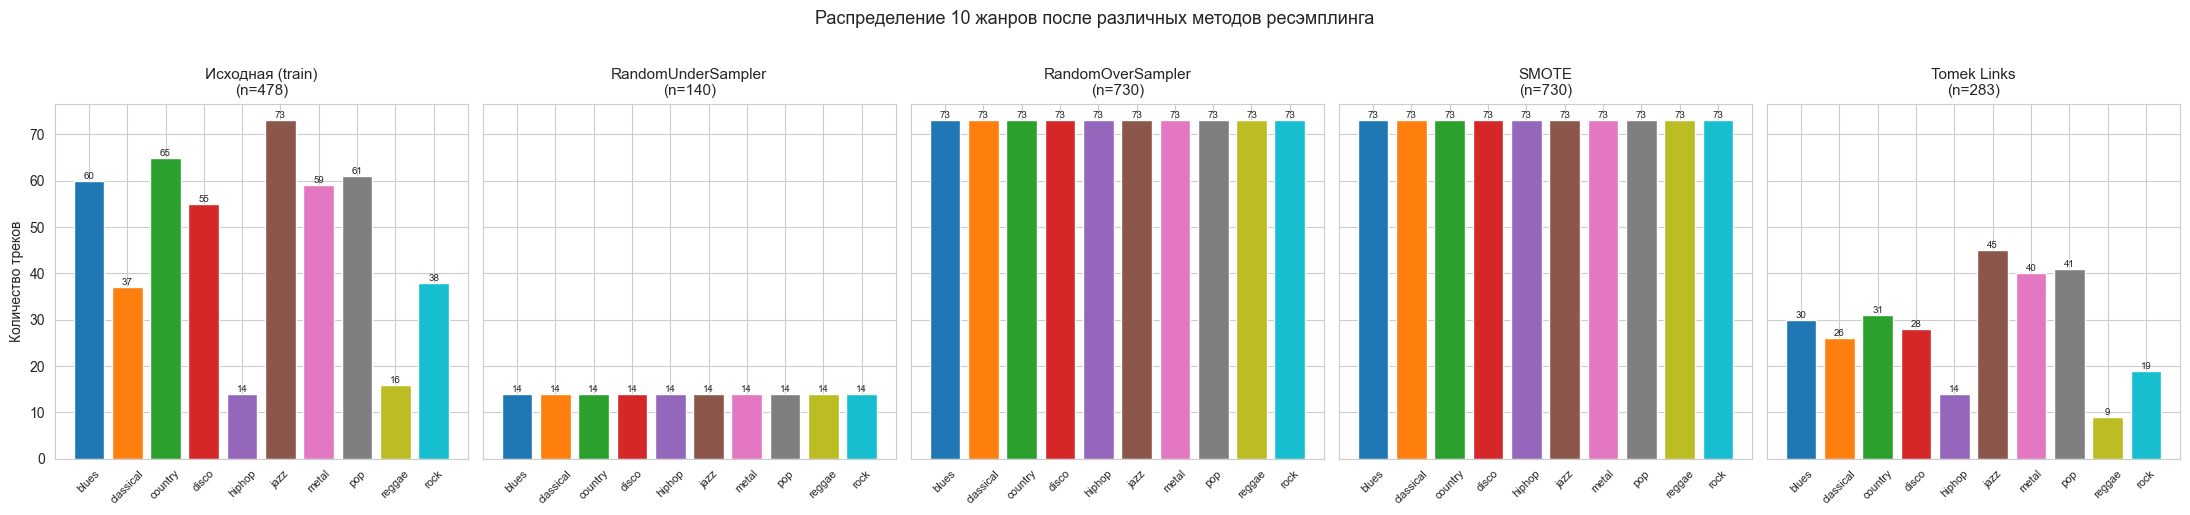

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

datasets = [
    ("Исходная (train)", y_train),
    ("RandomUnderSampler", y_under),
    ("RandomOverSampler", y_over),
    ("SMOTE", y_smote),
    ("Tomek Links", y_tomek),
]

palette = sns.color_palette("tab10", n_colors=len(GENRES))
genre_to_color = dict(zip(GENRES, palette))

for ax, (title, target) in zip(axes, datasets):
    counts = pd.Series(target).value_counts().reindex(GENRES, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=[genre_to_color[g] for g in counts.index])
    ax.set_title(f"{title}\n(n={len(target)})", fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    for bar in bars:
        ax.annotate(
            f"{int(bar.get_height())}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=7,
        )

axes[0].set_ylabel("Количество треков")
plt.suptitle("Распределение 10 жанров после различных методов ресэмплинга", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def stats(name, target):
    counts = pd.Series(target).value_counts()
    return {
        "Метод": name,
        "Всего": len(target),
        "Min класс": counts.min(),
        "Max класс": counts.max(),
        "Std": counts.std().round(1),
        "Imbalance ratio (max/min)": round(counts.max() / counts.min(), 2),
    }

results = pd.DataFrame([
    stats("Исходная (train)",   y_train),
    stats("RandomUnderSampler", y_under),
    stats("RandomOverSampler",  y_over),
    stats("SMOTE",              y_smote),
    stats("Tomek Links",        y_tomek),
])
results

,Метод,Всего,Min класс,Max класс,Std,Imbalance ratio (max/min)
0,Исходная (train),478,14,73,20.5,5.21
1,RandomUnderSampler,140,14,14,0.0,1.00
2,RandomOverSampler,730,73,73,0.0,1.00
3,SMOTE,730,73,73,0.0,1.00
4,Tomek Links,283,9,45,11.8,5.00


## Анализ распределения признаков после SMOTE

C:\Users\ichap\AppData\Local\Temp\ipykernel_49828\2636218704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="source", y="value",
C:\Users\ichap\AppData\Local\Temp\ipykernel_49828\2636218704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="source", y="value",
C:\Users\ichap\AppData\Local\Temp\ipykernel_49828\2636218704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="source", y="value",
C:\Users\ichap\AppData\Local\Temp\ipykernel_49828\2636218704.py:17: FutureWarning: 



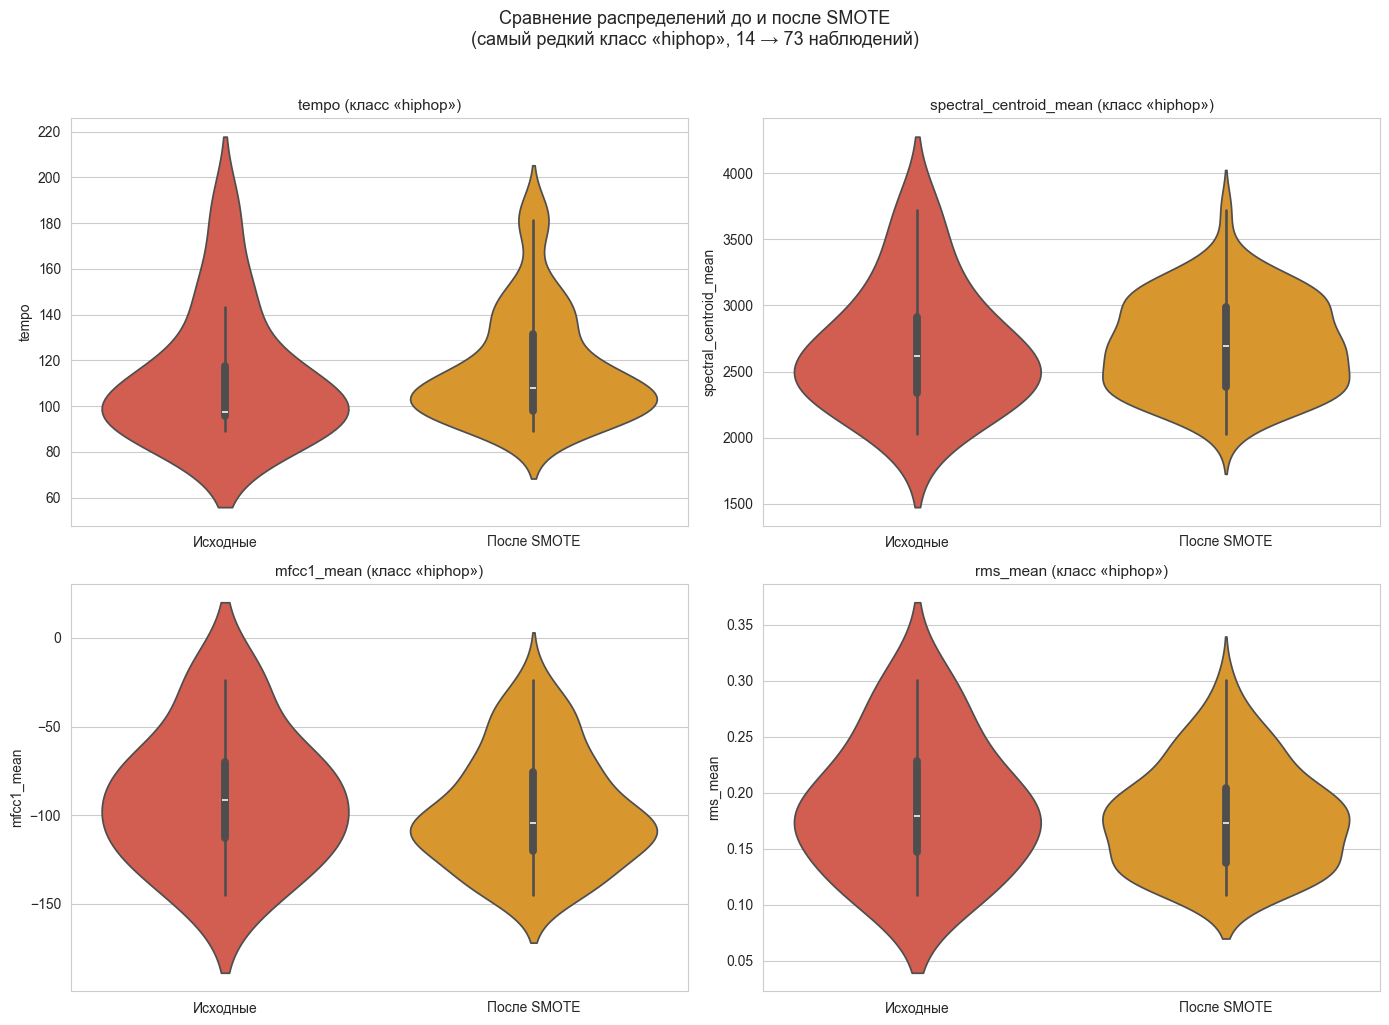

In [ ]:
min_class = y_train.value_counts().idxmin()
compare_features = ["tempo", "spectral_centroid_mean", "mfcc1_mean", "rms_mean"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.ravel(), compare_features):
    df_orig = pd.DataFrame({
        "value": X_train.loc[y_train == min_class, feat].values,
        "source": "Исходные",
    })
    df_sm = pd.DataFrame({
        "value": X_smote.loc[y_smote == min_class, feat].values,
        "source": "После SMOTE",
    })
    df_plot = pd.concat([df_orig, df_sm])

    sns.violinplot(data=df_plot, x="source", y="value",
                   palette=["#e74c3c", "#f39c12"], ax=ax)
    ax.set_title(f"{feat} (класс «{min_class}»)", fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel(feat)

plt.suptitle(
    f"Сравнение распределений до и после SMOTE\n"
    f"(самый редкий класс «{min_class}», "
    f"{(y_train == min_class).sum()} → {(y_smote == min_class).sum()} наблюдений)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

## Проверка SMOTE на дубликаты

In [ ]:
def per_class_dups(X_resampled, y_resampled, y_orig):
    rows = []
    for cls in sorted(y_resampled.unique()):
        mask_res = (y_resampled == cls)
        n_total = int(mask_res.sum())
        n_orig = int((y_orig == cls).sum())
        n_synthetic = n_total - n_orig
        n_dups = int(X_resampled.loc[mask_res].duplicated().sum())
        rows.append({
            "class": cls,
            "n_orig (train)": n_orig,
            "n_total (resampled)": n_total,
            "n_synthetic": max(n_synthetic, 0),
            "n_duplicates": n_dups,
        })
    return pd.DataFrame(rows)

print("=== SMOTE ===  (синтезирует промежуточные точки, не дубликаты)")
print(per_class_dups(X_smote, y_smote, y_train).to_string(index=False))

print("\n=== RandomOverSampler ===  (тупо копирует наблюдения)")
print(per_class_dups(X_over, y_over, y_train).to_string(index=False))

=== SMOTE ===  (синтезирует промежуточные точки, не дубликаты)
    class  n_orig (train)  n_total (resampled)  n_synthetic  n_duplicates
    blues              60                   73           13             0
classical              37                   73           36             0
  country              65                   73            8             0
    disco              55                   73           18             0
   hiphop              14                   73           59             0
     jazz              73                   73            0             0
    metal              59                   73           14             3
      pop              61                   73           12             0
   reggae              16                   73           57             0
     rock              38                   73           35             0

=== RandomOverSampler ===  (тупо копирует наблюдения)
    class  n_orig (train)  n_total (resampled)  n_synthetic  n_dupli

## Сравнение средних значений признаков

In [ ]:
# Сравним средние самого редкого класса до и после ресэмплинга
min_class = y_train.value_counts().idxmin()
compare_cols = ["tempo", "spectral_centroid_mean", "rms_mean", "mfcc1_mean", "mfcc2_mean"]

means = pd.DataFrame({
    "Исходные (train)": X_train.loc[y_train == min_class, compare_cols].mean(),
    "UnderSampler":     X_under.loc[y_under == min_class, compare_cols].mean(),
    "OverSampler":      X_over.loc[y_over == min_class, compare_cols].mean(),
    "SMOTE":            X_smote.loc[y_smote == min_class, compare_cols].mean(),
    "Tomek Links":      X_tomek.loc[y_tomek == min_class, compare_cols].mean(),
})

print(f"Средние значения признаков для самого редкого класса «{min_class}»:")
means.round(3)

Средние значения признаков для самого редкого класса «hiphop»:


,Исходные (train),UnderSampler,OverSampler,SMOTE,Tomek Links
tempo,112.999,112.999,116.087,117.191,112.999
spectral_centroid_mean,2682.690,2682.690,2628.419,2701.277,2682.690
rms_mean,0.188,0.188,0.186,0.178,0.188
mfcc1_mean,-90.207,-90.207,-89.767,-96.800,-90.207
mfcc2_mean,77.081,77.081,79.296,75.545,77.081


## Выводы

1. **Многоклассовый случайный дисбаланс.** Исходный GTZAN сбалансирован (10 жанров × 100). Для демонстрации сэмплинга мы искусственно дебалансировали каждый из 10 классов: для каждого жанра случайно (с фиксированным `random_state`) выбрана своя доля записей в диапазоне 10–100. Так получился реалистичный мультиклассовый сценарий с разным размером классов вместо тривиального «бинарного» случая.

2. **Правило NEPV.** При 57 признаках и нескольких десятках наблюдений в самых редких классах NEPV оказывается заметно ниже порога 10 — это формальный сигнал, что миноритарным классам не хватает данных для надёжной модели.

3. **Стратифицированное разбиение** сохранило пропорции 10 классов в `train` и `test` — без него редкие классы могли бы вообще исчезнуть из теста.

4. **Поведение методов на 10 классах:**
   - **RandomUnderSampler (`not minority`)**: уравнял всё до размера самого редкого класса — общий объём схлопывается, теряется много данных из крупных классов.
   - **RandomOverSampler (`not majority`)**: дублирует наблюдения редких классов до размера самого крупного. Балансирует, но создаёт массу одинаковых строк.
   - **SMOTE (`not majority`)**: то же выравнивание по верхней границе, но синтезирует промежуточные точки между ближайшими соседями (`k_neighbors` подобран по min классу), без точных дубликатов.
   - **Tomek Links (`auto`)**: чистит границы между классами, удаляя пары «соседей разных классов». Не балансирует, но улучшает разделимость — полезный preprocessing перед обучением.

5. **Что критически важно при мульти-классе:**
   - подобрать `k_neighbors` SMOTE по самому редкому классу (иначе падает с ошибкой);
   - стратифицировать `train_test_split` по `y` — иначе редкие классы могут исчезнуть из теста;
   - смотреть на размеры **всех** классов (Min/Max/Std/Imbalance ratio), а не только на «класс 0 / класс 1».